### Learning Rates are important
Learning Rate is a hyperparameter that indicates the models 'step size' while training. It is very sensative and changing it can affect traning time, accuracy and loss metrics.

I am going to do an expriement and test different Learning Rates on the same neural network with same task (classifying MNIST dataset) and rank diffrent values based on : Traning time, Testing accuracy, Testing loss

#### Values i want to test: [1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001]

In [7]:
#Change directory for importing 

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [8]:
#Load and preprocess MNIST dataset from keras
from load_mnist import load_handwritten_digits

X_train, y_train, X_test, y_test = load_handwritten_digits()

In [9]:
import time #For calculating training time

learning_rates = [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

accuracies = list()
losses = list()
times = list()

from build_model import build_mnist_model

In [10]:
btchsize = 32 #Best approved batch size

In [11]:
for indx, lr in enumerate(learning_rates):
    print(f"------------- Learning rate: {lr} ----------------")
    net = build_mnist_model(learning_rate= lr)

    start = time.perf_counter() #Timer starts!

    net.fit(X = X_train,
           y = y_train,
           epoch = 10,
           batch_size = btchsize,
           monitor_every_n = 10)

    elapsed = time.perf_counter() - start #Timer stops!
    times.append(elapsed)

    accuracy, loss = net.evaluate(X_test, y_test)
    
    accuracies.append(accuracy)
    losses.append(loss)

    print(f"Learning rate: {lr}, time: {elapsed}")
    print(f"Learning rate: {lr}, accuracy: {accuracy}")
    print(f"Learning rate: {lr}, loss: {loss}")

------------- Learning rate: 1 ----------------
epoch: 10, loss: 2.392814142339606
Learning rate: 1, time: 427.14399839995895
Learning rate: 1, accuracy: 0.0974
Learning rate: 1, loss: 2.3940065359597575
------------- Learning rate: 0.1 ----------------
epoch: 10, loss: 0.06925918713974404
Learning rate: 0.1, time: 202.5984067999525
Learning rate: 0.1, accuracy: 0.9703
Learning rate: 0.1, loss: 0.1117453115112411
------------- Learning rate: 0.01 ----------------
epoch: 10, loss: 0.03311852076228809
Learning rate: 0.01, time: 117.80355049995705
Learning rate: 0.01, accuracy: 0.9771
Learning rate: 0.01, loss: 0.07951026297035393
------------- Learning rate: 0.001 ----------------
epoch: 10, loss: 0.02574918419462986
Learning rate: 0.001, time: 115.93518329993822
Learning rate: 0.001, accuracy: 0.9778
Learning rate: 0.001, loss: 0.07682423589657295
------------- Learning rate: 0.0001 ----------------
epoch: 10, loss: 0.06863700379847823
Learning rate: 0.0001, time: 122.61707460007165
Lea

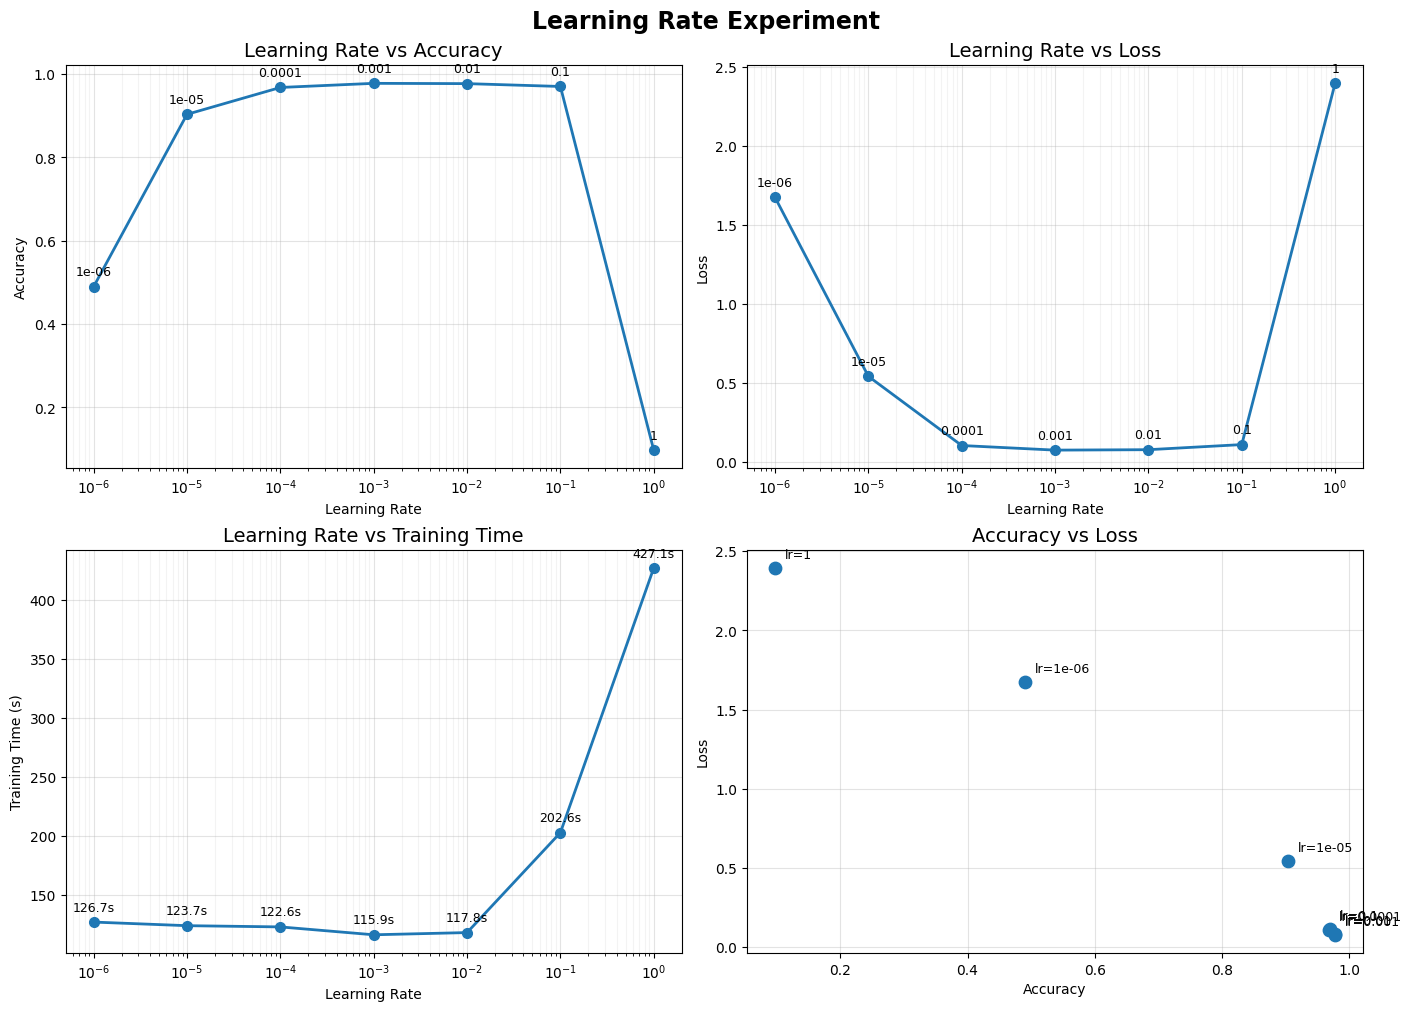

In [16]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    constrained_layout=True
)

# ============================================================
# 1. LEARNING RATE vs ACCURACY
# ============================================================

ax = axes[0, 0]

ax.plot(
    learning_rates,
    accuracies,
    marker="o",
    linewidth=2,
    markersize=7
)

ax.set_xscale("log")

ax.set_title("Learning Rate vs Accuracy", fontsize=14)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Accuracy")

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

# Label each point
for lr, acc in zip(learning_rates, accuracies):
    ax.annotate(
        f"{lr:g}",
        (lr, acc),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# ============================================================
# 2. LEARNING RATE vs LOSS
# ============================================================

ax = axes[0, 1]

ax.plot(
    learning_rates,
    losses,
    marker="o",
    linewidth=2,
    markersize=7
)

ax.set_xscale("log")

ax.set_title("Learning Rate vs Loss", fontsize=14)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Loss")

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

for lr, loss in zip(learning_rates, losses):
    ax.annotate(
        f"{lr:g}",
        (lr, loss),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# ============================================================
# 3. LEARNING RATE vs TRAINING TIME
# ============================================================

ax = axes[1, 0]

ax.plot(
    learning_rates,
    times,
    marker="o",
    linewidth=2,
    markersize=7
)

ax.set_xscale("log")

ax.set_title("Learning Rate vs Training Time", fontsize=14)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Training Time (s)")

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

for lr, t in zip(learning_rates, times):
    ax.annotate(
        f"{t:.1f}s",
        (lr, t),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# ============================================================
# 4. ACCURACY vs LOSS
# ============================================================

ax = axes[1, 1]

ax.scatter(
    accuracies,
    losses,
    s=80
)

ax.set_title("Accuracy vs Loss", fontsize=14)
ax.set_xlabel("Accuracy")
ax.set_ylabel("Loss")

ax.grid(True, alpha=0.35)

# Label every point with its learning rate
for lr, acc, loss in zip(learning_rates, accuracies, losses):
    ax.annotate(
        f"lr={lr:g}",
        (acc, loss),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

# ============================================================
# FINAL
# ============================================================

fig.suptitle(
    "Learning Rate Experiment",
    fontsize=17,
    fontweight="bold"
)

plt.savefig("test_results\\learning_rate_test.png")

plt.show()